In [1]:
import numpy as np
import pandas as pd
import re
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import collections
import itertools
import seaborn as sns
import tweepy
import datetime
import nltk
from nltk.corpus import stopwords
from PIL import Image
import datetime
from afinn import Afinn
from nltk.stem.porter import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from nltk.stem import WordNetLemmatizer 
from sklearn.feature_extraction.text import TfidfVectorizer
import operator
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from networkx.drawing.nx_agraph import graphviz_layout
import nltk

In [2]:
df = pd.read_excel('C:/Users/jwan0/Youtubecrawl_JP_1108.xlsx')

df.head()

,id,content of comments,Translation
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...


In [3]:
df = df.astype('string')
df.dtypes

id                     string[python]
content of comments    string[python]
Translation            string[python]
dtype: object

In [4]:
df['Translation'] = df['Translation'].astype(str).str.lower()
df.head()

,id,content of comments,Translation
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...


In [5]:
from nltk.tokenize import RegexpTokenizer

regexp = RegexpTokenizer('\w+')

df['text_token']=df['Translation'].apply(regexp.tokenize)
df.head()

,id,content of comments,Translation,text_token
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan, from, italy]"
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,..."
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, is, such, a, wonder, to, me, love, fro..."
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[i, m, currently, learning, japanese, and, whe..."
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, this, video, makes, me, feel, happy..."


In [6]:
stopwords = nltk.corpus.stopwords.words("english")

# Extend the list with your own custom stopwords
my_stopwords = ['https', 'and', 'this','from','you','that','for','was','are','can','but','all','who','what','where','your','really',
                'made', 'well', 'anyone','guys','name','much', 'put','ever','could', 'one', 'done','come','www','may', 'hey', 'chan',
                'someday', 'still','yet','somehow','first', 'yoooo', '2021', '2020', 'truly', '2019','also', 'degree', 'units', 'skip', 
                'hello', 'soon', 'even', 'really', 'going','greeting', 'next','looks', 'ahhhh', 'desu', 'get', 'got', 'guy', 
                'make', 'makes', 'qua','watashi', 'okay', 'yuri', 'com', 'back', 'wait', 'thought','past', 'would', 'lot', 'let', 'though','take',
                "br", 'ji', '18', 'kuvaev', 'sergey' , 'sam', 'yes', 'right', 'single', 'many', '170', '102', 'whats', '100', 'mrs',
                'always', 'haha', 'two', 'yeah', 'anybody', 'thing', 'whole', 'rrulong', 'tennis', 'meh', 'mix', 'hard', 'wtf',
                'shalom', 'samira', 'ann', 'john', 'cena', 'damn', 'zmm', 'meryl', 'rafa', 'simply', 'amazon', 'another', 'wynona',
                'xxx', 'arbaz', 'totally', 'indian', 'way', 'asian', 'maria', 'lusie','fascist', 'helicopter', 'please', 'spain',
                'jam', 'hahaha', 'hahahaha', 'something', 'every', 'part', 'keep', '000', 'away', 'full', 'find', 'without',
                'hehe', 'pas', 'ban', 'body', 'search', 'fill', 'front', 'shit', 'else', 'kind', 'year', 'already', 'goblin',
                'since', 'reference', 'version', 'time', 'finally', 'indonesia', 'episode', 'yoo', 'kim', 'adidas', 'heh', 'man',
                'exam', 'italy', 'similar', 'definitely', 'korea', 'philippine', 'india', 'china', 'bangladesh', 'türki', 'thai',
                'blade', 'runner' ,'cambodia' ,'around', 'school', 'recurrently', 'second', 'big', 'rather', 'singapore', 'bear',
                'mexico', 'spit', '2015', 'shampoo', 'matter', 'month', 'greece', 'october', 'middle', 'hundred', 'rat', 'uwu',
                'exactly', 'anything', 'chunithm', 'germany', 'american', 'politics', 'zanshin', 'otaku', 'uncouth', 'sometimes',
                'becp,e']

stopwords.extend(my_stopwords)

In [7]:
df['text_token'] = df['text_token'].apply(lambda x: [item for item in x if item not in stopwords])
df.head()

,id,content of comments,Translation,text_token
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]"
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,..."
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]"
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re..."
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful..."


In [8]:
df['text_string'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if len(item)>2]))

df.head()

,id,content of comments,Translation,text_token,text_string
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...


In [9]:
df[['Translation', 'text_token', 'text_string']].head()

,Translation,text_token,text_string
0,love japan! from italy 🇮🇹,"[love, japan]",love japan
1,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...
2,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love
3,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...
4,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...


In [10]:
#nltk.download('punkt')

#Create a list of all words
all_words = ' '.join([word for word in df['text_string']])

#Tokenize all_words
tokenized_words = nltk.tokenize.word_tokenize(all_words)

#Create a frequency distribution which records the number of times each word has occurred:

from nltk.probability import FreqDist

fdist = FreqDist(tokenized_words)
fdist

FreqDist({'japan': 735, 'love': 301, 'video': 240, 'country': 137, 'japanese': 131, 'beautiful': 129, 'like': 110, 'want': 89, 'people': 74, 'amazing': 74, ...})

In [11]:
df['text_string_fdist'] = df['text_token'].apply(lambda x: ' '.join([item for item in x if fdist[item] >= 1 ]))

In [12]:
df[['Translation','text_token', 'text_string', 'text_string_fdist']].head()

,Translation,text_token,text_string,text_string_fdist
0,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan
1,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...
2,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love
3,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...
4,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...


In [13]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    words = text.split()
    words = [lemmatizer.lemmatize(word,pos='v') for word in words]
    words = [lemmatizer.lemmatize(word,pos='n') for word in words]
    return ' '.join(words)
df['text_string_lem'] = df['text_string_fdist'].apply(lemmatize_words)

In [14]:
df['is_equal']= (df['text_string_fdist']==df['text_string_lem'])

In [15]:
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan,love japan,True
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love,japan wonder love,True
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...,watch video feel happy bear beautiful country ...,False


In [16]:
df = df.dropna()
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan,love japan,True
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love,japan wonder love,True
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...,watch video feel happy bear beautiful country ...,False


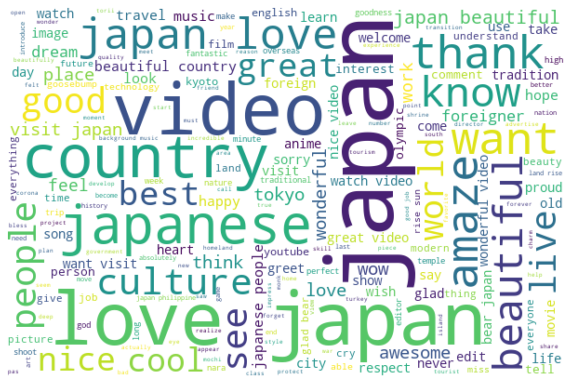

In [17]:
from wordcloud import WordCloud

all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(width=600, 
                     height=400, 
                     random_state=2, 
                     background_color='white', 
                     max_font_size=100).generate(all_words_lem)


plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

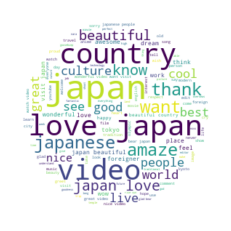

In [18]:
x, y = np.ogrid[:300, :300]
mask = (x - 150) ** 2 + (y - 150) ** 2 > 130 ** 2
mask = 255 * mask.astype(int)

wc = WordCloud(background_color="white", repeat=True, mask=mask)
wc.generate(all_words_lem)

plt.axis("off")
plt.imshow(wc, interpolation="bilinear");

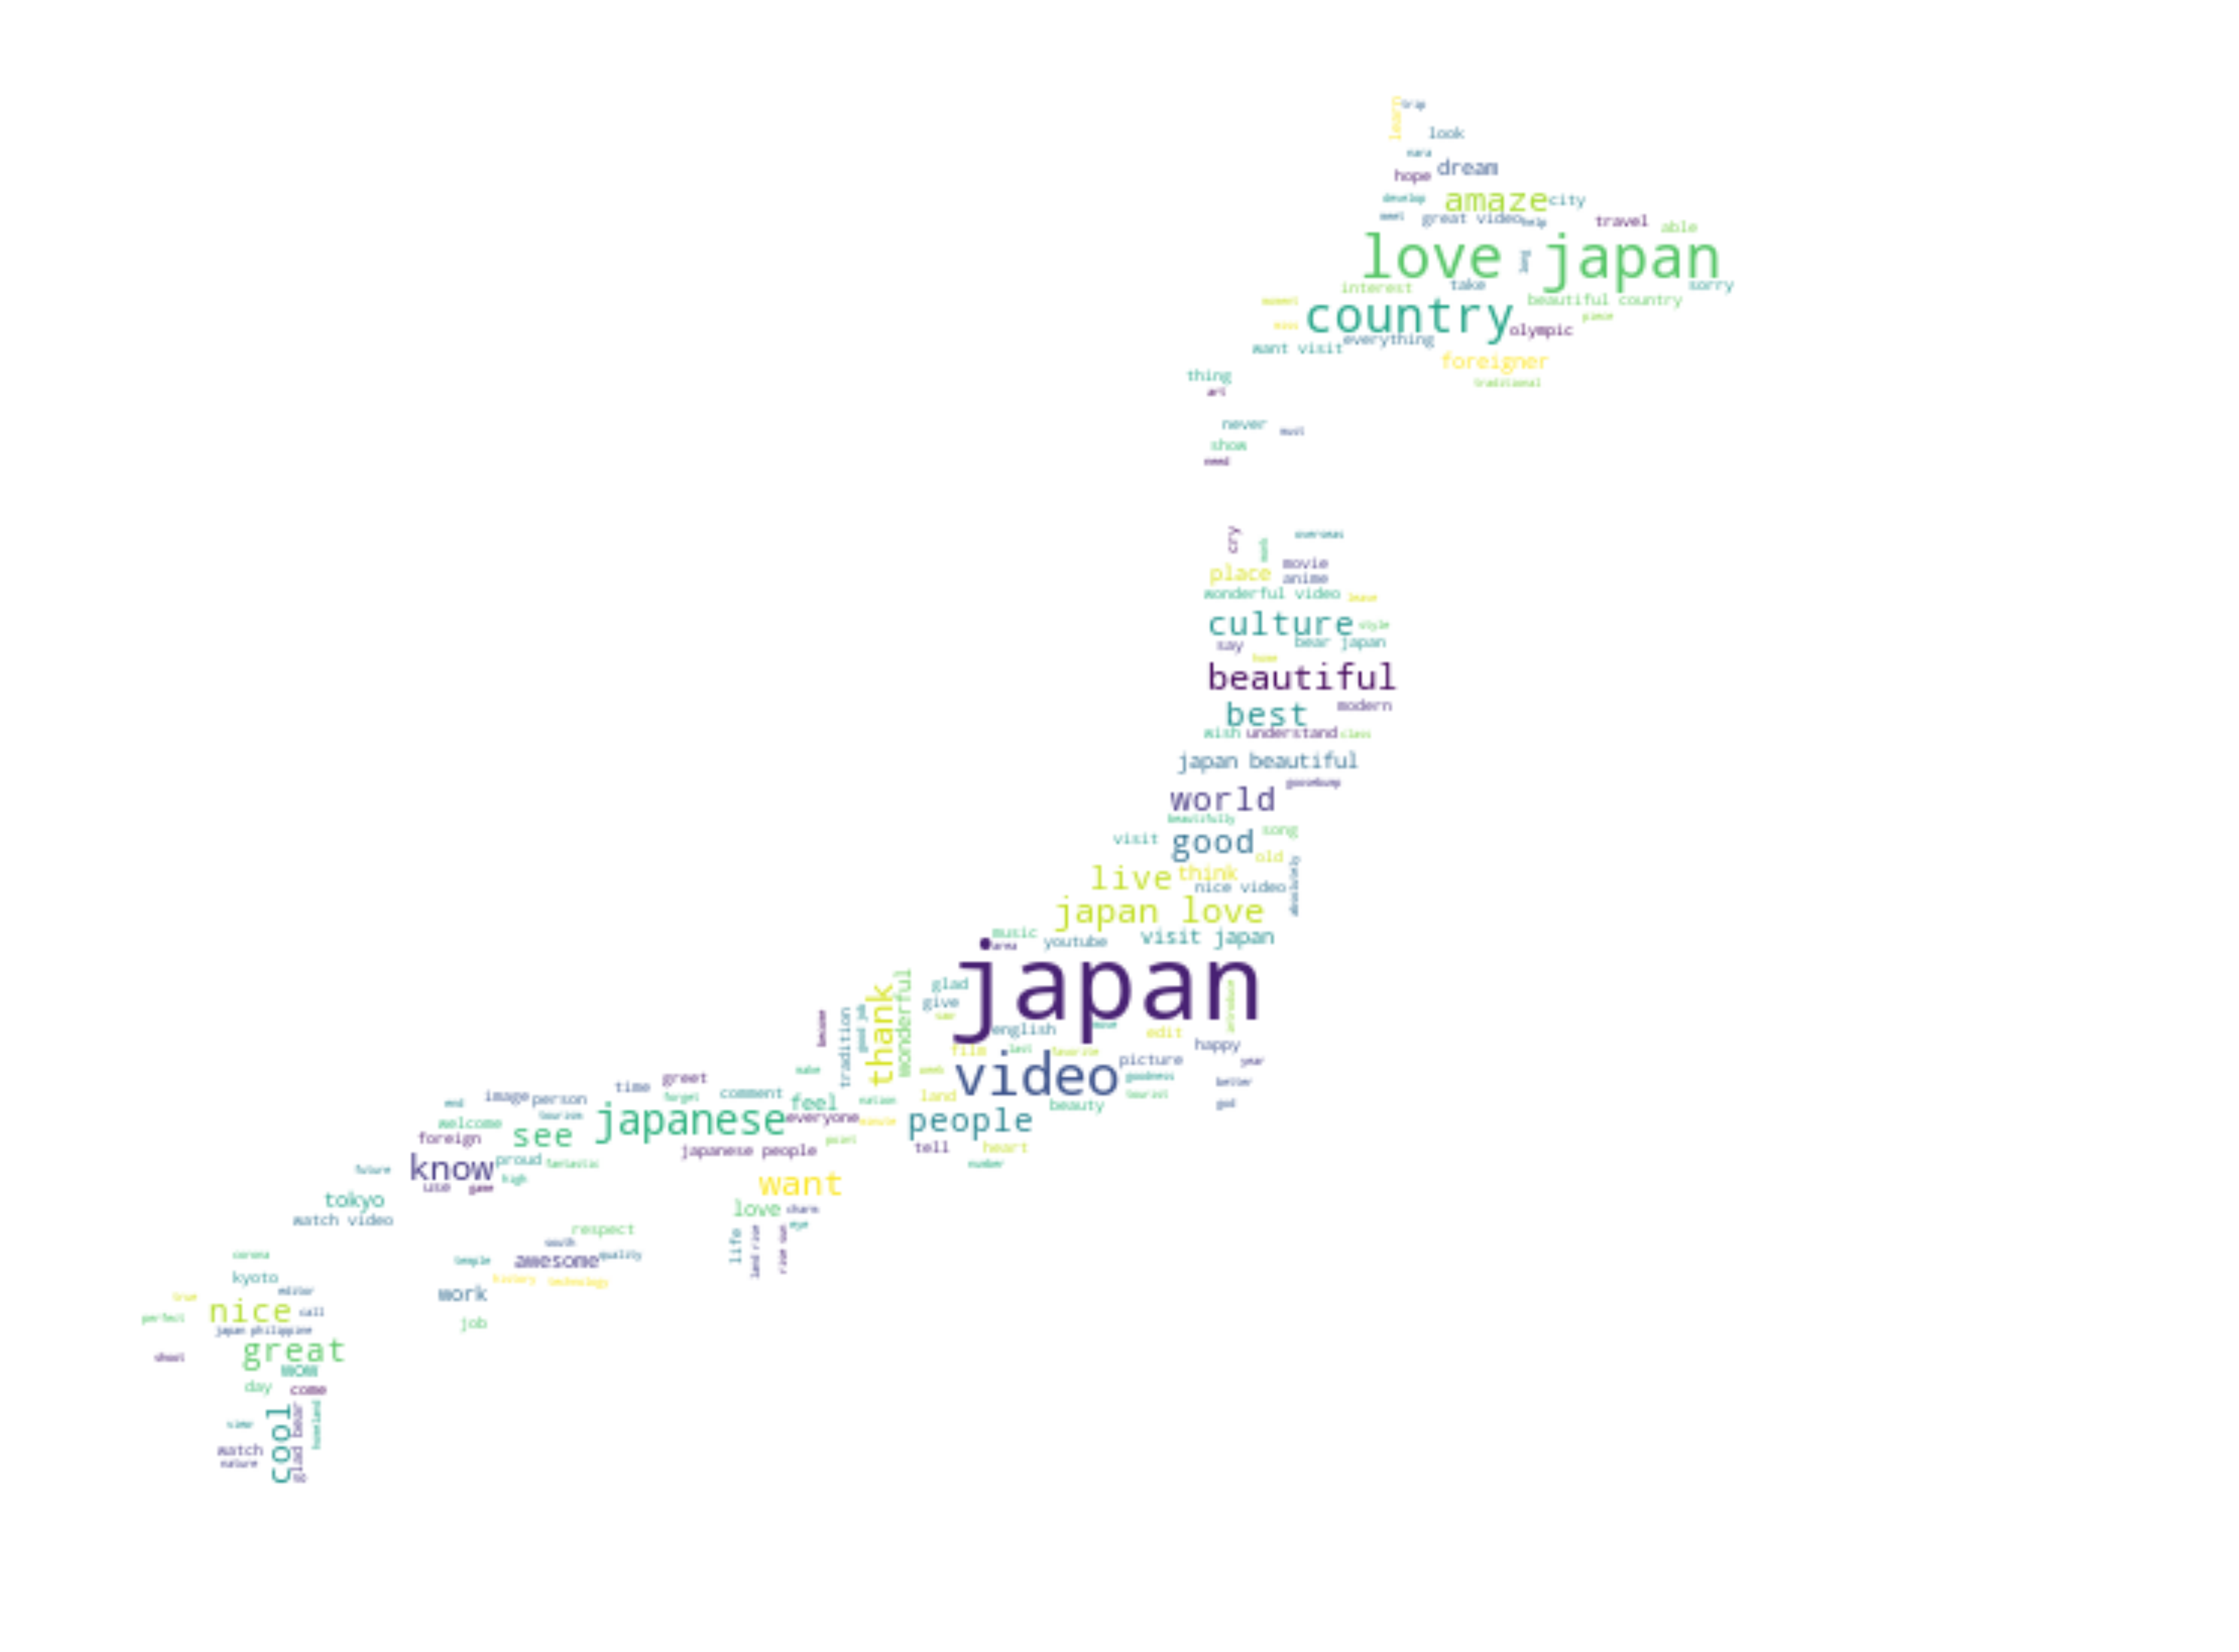

In [19]:
from wordcloud import WordCloud
mask = np.array(Image.open(r'C:\Users\jwan0\Geomap-asia-Japan.png'))
all_words_lem = ' '.join([word for word in df['text_string_lem']])

wordcloud = WordCloud(random_state=2, 
                     background_color='white', 
                     mask = mask,
                     width = mask.shape[1],
                     height = mask.shape[0],
                     max_font_size=500).generate(all_words_lem)


plt.figure(figsize=(100, 80))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off');

In [20]:
#Word frequency list

from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

words = nltk.word_tokenize(all_words_lem)
fd = FreqDist(words)

In [21]:
fd.most_common(200)

[('japan', 737),
 ('love', 316),
 ('video', 257),
 ('country', 160),
 ('japanese', 131),
 ('beautiful', 129),
 ('like', 112),
 ('want', 95),
 ('thank', 76),
 ('amaze', 75),
 ('people', 74),
 ('know', 68),
 ('visit', 64),
 ('great', 61),
 ('culture', 52),
 ('nice', 51),
 ('good', 51),
 ('see', 49),
 ('wonderful', 49),
 ('live', 45),
 ('world', 43),
 ('best', 41),
 ('cool', 39),
 ('place', 36),
 ('watch', 36),
 ('awesome', 36),
 ('think', 35),
 ('tokyo', 34),
 ('wow', 34),
 ('feel', 31),
 ('bear', 31),
 ('music', 31),
 ('work', 30),
 ('foreigner', 28),
 ('dream', 27),
 ('look', 27),
 ('happy', 26),
 ('hope', 25),
 ('glad', 24),
 ('travel', 24),
 ('come', 21),
 ('say', 21),
 ('edit', 20),
 ('use', 20),
 ('respect', 19),
 ('tradition', 19),
 ('never', 18),
 ('day', 18),
 ('land', 18),
 ('city', 18),
 ('proud', 17),
 ('image', 17),
 ('welcome', 16),
 ('show', 16),
 ('job', 16),
 ('movie', 16),
 ('learn', 15),
 ('greet', 15),
 ('wish', 15),
 ('comment', 15),
 ('take', 14),
 ('anime', 14),
 (

In [22]:
word_rank = fd.most_common(200)

WR = pd.DataFrame(word_rank)

WR.to_excel('Word_top_200_sw.xlsx')

In [23]:
top_20 = fd.most_common(20)

fdist = pd.Series(dict(top_20))

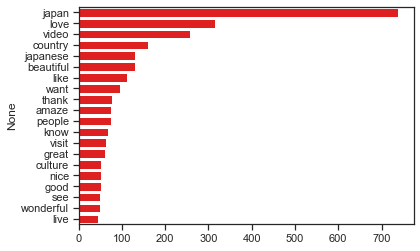

In [24]:
sns.set_theme(style="ticks")

sns.barplot(y=fdist.index, x=fdist.values, color='red');

In [25]:
from nltk.sentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

df['polarity'] = df['text_string_lem'].apply(lambda x: analyzer.polarity_scores(x))
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,polarity
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan,love japan,True,"{'neg': 0.0, 'neu': 0.192, 'pos': 0.808, 'comp..."
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,"{'neg': 0.049, 'neu': 0.854, 'pos': 0.097, 'co..."
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love,japan wonder love,True,"{'neg': 0.0, 'neu': 0.323, 'pos': 0.677, 'comp..."
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,"{'neg': 0.0, 'neu': 0.792, 'pos': 0.208, 'comp..."
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...,watch video feel happy bear beautiful country ...,False,"{'neg': 0.0, 'neu': 0.397, 'pos': 0.603, 'comp..."


In [26]:
df = pd.concat(
    [df.drop(['polarity'], axis=1), df['polarity'].apply(pd.Series)], axis=1)
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan,love japan,True,0.000,0.192,0.808,0.6369
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,0.049,0.854,0.097,0.5719
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love,japan wonder love,True,0.000,0.323,0.677,0.6369
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,0.000,0.792,0.208,0.6369
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...,watch video feel happy bear beautiful country ...,False,0.000,0.397,0.603,0.9918


In [27]:
df['sentiment'] = df['compound'].apply(lambda x: 'positive' if x >0 else 'neutral'if x==0 else 'negative')
df.head()

,id,content of comments,Translation,text_token,text_string,text_string_fdist,text_string_lem,is_equal,neg,neu,pos,compound,sentiment
0,Alessio Barone,I LOVE JAPAN! From Italy 🇮🇹,love japan! from italy 🇮🇹,"[love, japan]",love japan,love japan,love japan,True,0.000,0.192,0.808,0.6369,positive
1,T Take,0:01 TOKYO SKYTRE0:02 Tokyo Tower0:08 Toudai-j...,0:01 tokyo skytre 0:02 tokyo tower 0:08 toudai...,"[0, 01, tokyo, skytre, 0, 02, tokyo, tower, 0,...",tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,tokyo skytre tokyo tower toudai temple know ts...,False,0.049,0.854,0.097,0.5719,positive
2,KF,Japan is such a wonder to me. Love from India!...,japan is such a wonder to me. love from india!...,"[japan, wonder, love]",japan wonder love,japan wonder love,japan wonder love,True,0.000,0.323,0.677,0.6369,positive
3,Thijmen,I'm currently learning Japanese and when I see...,i'm currently learning japanese and when i see...,"[currently, learning, japanese, see, video, re...",currently learning japanese see video reminds ...,currently learning japanese see video reminds ...,currently learn japanese see video remind lear...,False,0.000,0.792,0.208,0.6369,positive
4,あめ,この動画を見ると改めてこの美しい国に生まれてよかったなと思います。私達日本人にも再度日本の魅...,watching this video makes me feel happy to be ...,"[watching, video, feel, happy, born, beautiful...",watching video feel happy born beautiful count...,watching video feel happy born beautiful count...,watch video feel happy bear beautiful country ...,False,0.000,0.397,0.603,0.9918,positive


In [28]:
df.loc[df['compound'].idxmax()].values
print()
# Tweet with highest negative sentiment 
# ...seems to be a case of wrong classification because of the word "deficit"
df.loc[df['compound'].idxmin()].values

array(['  bni',
       '日本の悪いところと言われる長時間労働や自殺率。まさに自分が精神科にかかり続けてる社畜だけどこの国を恨んだことは一度もない',
       "long working hours and suicide rate are said to be bad points in japan. i'm a social slave who keeps going to a psychiatrist, but i've never held a grudge against this country.",
       list(['long', 'working', 'hours', 'suicide', 'rate', 'said', 'bad', 'points', 'japan', 'social', 'slave', 'keeps', 'psychiatrist', 'never', 'held', 'grudge', 'country']),
       'long working hours suicide rate said bad points japan social slave keeps psychiatrist never held grudge country',
       'long working hours suicide rate said bad points japan social slave keeps psychiatrist never held grudge country',
       'long work hour suicide rate say bad point japan social slave keep psychiatrist never hold grudge country',
       False, 0.348, 0.652, 0.0, -0.8402, 'negative'], dtype=object)

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_22828/1332496738.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment',


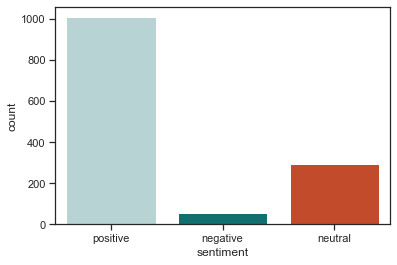

In [29]:
sns.countplot(x='sentiment', 
             data=df, 
             palette=['#b2d8d8',"#008080", '#db3d13']
             );

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_22828/2680373653.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y='compound',


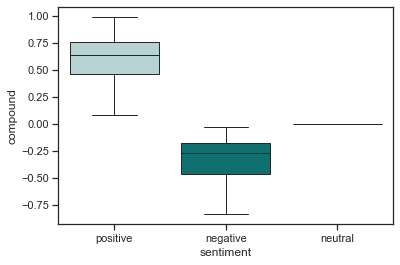

In [30]:
sns.boxplot(y='compound', 
            x='sentiment',
            palette=['#b2d8d8',"#008080", '#db3d13'], 
            data=df);

In [31]:
WR.to_excel('Word_top_200_sw.xlsx')

In [32]:
#social network
translated_text = df['text_string_lem']
translated_text.reset_index(inplace=True, drop=True) # 인덱스 초기화

In [33]:
tokenizer = RegexpTokenizer('[\w]+')

count = {} # 동시출현 빈도가 저장될 dict

for line in translated_text:
    words = line
    tokens = tokenizer.tokenize(words) # 각 리뷰를 토큰화한 뒤 리스트에 저장
    stopped_tokens = [i for i in list(set(tokens)) if not i in stopwords]
    stopped_tokens2 = [i for i in stopped_tokens if len(i)>1]
    for i,a in enumerate(stopped_tokens2):
        for b in stopped_tokens2[i+1:]:
            if a>b:
                count[b,a] = count.get((b,a),0) + 1
            else:
                count[a,b] = count.get((a,b),0) + 1
                
df1 = pd.DataFrame.from_dict(count, orient='index')

list1=[]
for i in range(len(df)):
    list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])

df2 = pd.DataFrame(list1, columns=['term1','term2','freq'])
df3 = df2.sort_values(by=['freq'], ascending=False) # freq 기준으로 내림차순 정렬
df3_nw = df3.reset_index(drop=True)

C:\Users\Public\Documents\ESTsoft\CreatorTemp/ipykernel_22828/3785069860.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  list1.append([df1.index[i][0], df1.index[i][1], df1[0][i]])


In [34]:
YT_jp_nw = nx.Graph()
n = 1
# 동시출현 빈도가 n초과인 단어들에 대해서만 중심성 계수 계산
for i in range((len(np.where(df3_nw['freq']>n)[0]))):
    YT_jp_nw.add_edge(df3_nw['term1'][i], df3_nw['term2'][i],
                  weight=int(df3_nw['freq'][i]))

dgr = nx.degree_centrality(YT_jp_nw) # 연결 중심성
btw = nx.betweenness_centrality(YT_jp_nw) # 매개 중심성
cls = nx.closeness_centrality(YT_jp_nw) # 근접 중심성
egv = nx.eigenvector_centrality(YT_jp_nw) # 고유벡터 중심성

sorted_dgr = sorted(dgr.items(), key=operator.itemgetter(1), reverse=True)
sorted_btw = sorted(btw.items(), key=operator.itemgetter(1), reverse=True)
sorted_cls = sorted(cls.items(), key=operator.itemgetter(1), reverse=True)
sorted_egv = sorted(egv.items(), key=operator.itemgetter(1), reverse=True)

print("** degree **")
for x in range(20):
    print(sorted_dgr[x])

print("** betweenness **")
for x in range(20):
    print(sorted_btw[x])
    
print("** closeness **")
for x in range(20):
    print(sorted_cls[x])

print("** eigenvector **")
for x in range(20):
    print(sorted_egv[x])

** degree **
('japanese', 0.631578947368421)
('know', 0.47368421052631576)
('temple', 0.3684210526315789)
('japan', 0.3157894736842105)
('place', 0.15789473684210525)
('tokyo', 0.10526315789473684)
('sorry', 0.10526315789473684)
('science', 0.10526315789473684)
('market', 0.10526315789473684)
('waterfall', 0.10526315789473684)
('national', 0.10526315789473684)
('love', 0.05263157894736842)
('art', 0.05263157894736842)
('innovation', 0.05263157894736842)
('arcade', 0.05263157894736842)
('tsukiji', 0.05263157894736842)
('emerge', 0.05263157894736842)
('beckon', 0.05263157894736842)
('zen', 0.05263157894736842)
('nakatani', 0.05263157894736842)
** betweenness **
('japanese', 0.5077972709551657)
('know', 0.29191033138401556)
('japan', 0.25389863547758285)
('temple', 0.24756335282651068)
('place', 0.021929824561403508)
('market', 0.021929824561403508)
('love', 0.0)
('tokyo', 0.0)
('art', 0.0)
('sorry', 0.0)
('science', 0.0)
('innovation', 0.0)
('arcade', 0.0)
('tsukiji', 0.0)
('waterfall', 

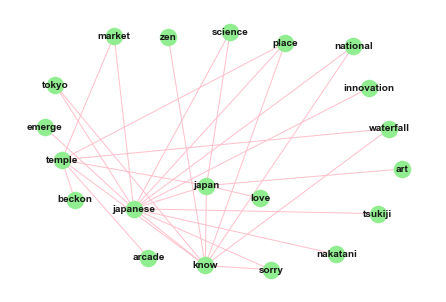

<Figure size 2e+06x2e+06 with 0 Axes>

In [35]:
nx.draw(YT_jp_nw, pos = nx.spring_layout(YT_jp_nw, k=5),
    node_color='lightgreen', linewidths=0.125, font_size=10,
    font_weight='bold', edge_color= 'pink', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

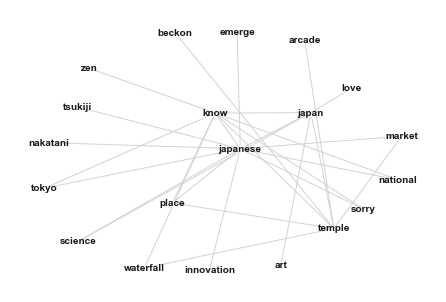

<Figure size 2e+06x2e+06 with 0 Axes>

In [36]:
nx.draw(YT_jp_nw, pos = nx.spring_layout(YT_jp_nw, k=3),
    node_color='white', linewidths=0, font_size=10, node_size = 50,
    font_weight='bold', edge_color= 'lightgrey', with_labels=True)

plt.figure(num=None, figsize=(2000, 2000), dpi=1000)


plt.show()

In [37]:
#LDA Topic modeling
stop_words = stopwords

vect =TfidfVectorizer(stop_words=stop_words,max_features=1000)
vect_text=vect.fit_transform(df['text_string_lem'])

In [38]:
from sklearn.decomposition import LatentDirichletAllocation
lda_model=LatentDirichletAllocation(n_components=10,
learning_method='online',random_state=42,max_iter=1) 
lda_top=lda_model.fit_transform(vect_text)

In [39]:
print("Document : ")
for i,topic in enumerate(lda_top[0]):
  print("Topic ",i+1,": ",topic*100,"%")

Document : 
Topic  1 :  4.1743433615268195 %
Topic  2 :  4.1743276945059336 %
Topic  3 :  62.43066353249671 %
Topic  4 :  4.174330102624334 %
Topic  5 :  4.1743293155965855 %
Topic  6 :  4.174312274765676 %
Topic  7 :  4.1744258437973425 %
Topic  8 :  4.1744982791837355 %
Topic  9 :  4.174312208913981 %
Topic  10 :  4.174457386588885 %


In [40]:
vocab = vect.get_feature_names()
for i, comp in enumerate(lda_model.components_):
     vocab_comp = zip(vocab, comp)
     sorted_words = sorted(vocab_comp, key= lambda x:x[1], reverse=True)[:10]
     print("Topic "+str(i+1)+": ")
     for t in sorted_words:
            print(t[0],end=" ")
            print('\n')

Topic 1: 
film 

girl 

cute 

art 

japanese 

tear 

ruby 

become 

show 

japan 

Topic 2: 
wow 

mochi 

monk 

advertise 

need 

word 

good 

beat 

earth 

yokohama 

Topic 3: 
japan 

love 

beautiful 

want 

like 

cool 

video 

thank 

country 

japanese 

Topic 4: 
nakagawa 

wish 

ninja 

hiroshima 

japan 

smooth 

wonderland 

remember 

clean 

palace 

Topic 5: 
god 

beauty 

impress 

night 

tang 

shoot 

people 

style 

pleasure 

park 

Topic 6: 
sorry 

goosebump 

fukushima 

kyoto 

fine 

situation 

tokyo 

wear 

hiroshima 

give 

Topic 7: 
see 

youtube 

look 

good 

japan 

proud 

cry 

welcome 

japanese 

country 

Topic 8: 
great 

awesome 

video 

japan 

greet 

miss 

love 

good 

minute 

country 

Topic 9: 
song 

music 

video 

movie 

background 

edit 

awesome 

tell 

know 

use 

Topic 10: 
amaze 

video 

nice 

wonderful 

glad 

japan 

country 

wow 

watch 

learn 



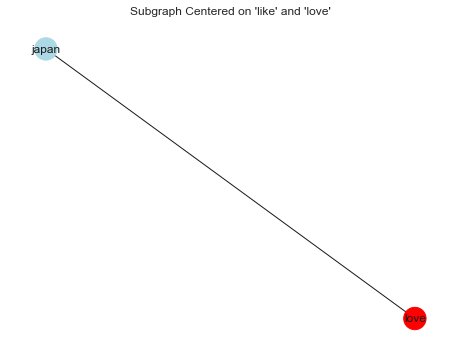

In [41]:
# Define your center keywords
center_keywords = 'love'

# Ensure these nodes exist in the full network
center_nodes = [node for node in YT_jp_nw.nodes() if node in center_keywords]

# Collect all neighbors (1-hop) of the center keywords
neighbors = set()
for node in center_nodes:
    neighbors.update(nx.all_neighbors(YT_jp_nw, node))
# Also include the center nodes themselves
neighbors.update(center_nodes)

# Create the subgraph
subgraph = YT_jp_nw.subgraph(neighbors)

# (Optional) Compute centrality measures for additional insight
degree_cent = nx.degree_centrality(subgraph)
betweenness_cent = nx.betweenness_centrality(subgraph)
closeness_cent = nx.closeness_centrality(subgraph)
eigenvector_cent = nx.eigenvector_centrality(subgraph)


# Visualize the subgraph
pos = nx.spring_layout(subgraph, seed=42)
node_colors = ['red' if node in center_keywords else 'lightblue' for node in subgraph.nodes()]

plt.figure(figsize=(8, 6))
nx.draw_networkx_nodes(subgraph, pos, node_color=node_colors, node_size=500)
nx.draw_networkx_edges(subgraph, pos)
nx.draw_networkx_labels(subgraph, pos)
plt.title("Subgraph Centered on 'like' and 'love'")
plt.axis('off')
plt.show()

In [42]:
# Create a DataFrame to combine these centrality measures
centralities_table = pd.DataFrame({
    'Node': list(subgraph.nodes()),
    'Degree': [degree_cent[node] for node in subgraph.nodes()],
    'Betweenness': [betweenness_cent[node] for node in subgraph.nodes()],
    'Closeness': [closeness_cent[node] for node in subgraph.nodes()],
    'Eigenvector': [eigenvector_cent[node] for node in subgraph.nodes()]
})

# Sort the table by Degree centrality (or any other measure) for easier interpretation
centralities_table = centralities_table.sort_values(by='Degree', ascending=False)

# Display the table
print(centralities_table)

    Node  Degree  Betweenness  Closeness  Eigenvector
0  japan     1.0          0.0        1.0     0.707107
1   love     1.0          0.0        1.0     0.707107


Topic 1: ['film', 'girl', 'cute', 'art', 'japanese', 'tear', 'ruby', 'become', 'show', 'japan']
Topic 2: ['wow', 'mochi', 'monk', 'advertise', 'need', 'word', 'good', 'beat', 'earth', 'yokohama']
Topic 3: ['japan', 'love', 'beautiful', 'want', 'like', 'cool', 'video', 'thank', 'country', 'japanese']
Topic 4: ['nakagawa', 'wish', 'ninja', 'hiroshima', 'japan', 'smooth', 'wonderland', 'remember', 'clean', 'palace']
Topic 5: ['god', 'beauty', 'impress', 'night', 'tang', 'shoot', 'people', 'style', 'pleasure', 'park']
Topic 6: ['sorry', 'goosebump', 'fukushima', 'kyoto', 'fine', 'situation', 'tokyo', 'wear', 'hiroshima', 'give']
Topic 7: ['see', 'youtube', 'look', 'good', 'japan', 'proud', 'cry', 'welcome', 'japanese', 'country']
Topic 8: ['great', 'awesome', 'video', 'japan', 'greet', 'miss', 'love', 'good', 'minute', 'country']
Topic 9: ['song', 'music', 'video', 'movie', 'background', 'edit', 'awesome', 'tell', 'know', 'use']
Topic 10: ['amaze', 'video', 'nice', 'wonderful', 'glad', 'ja

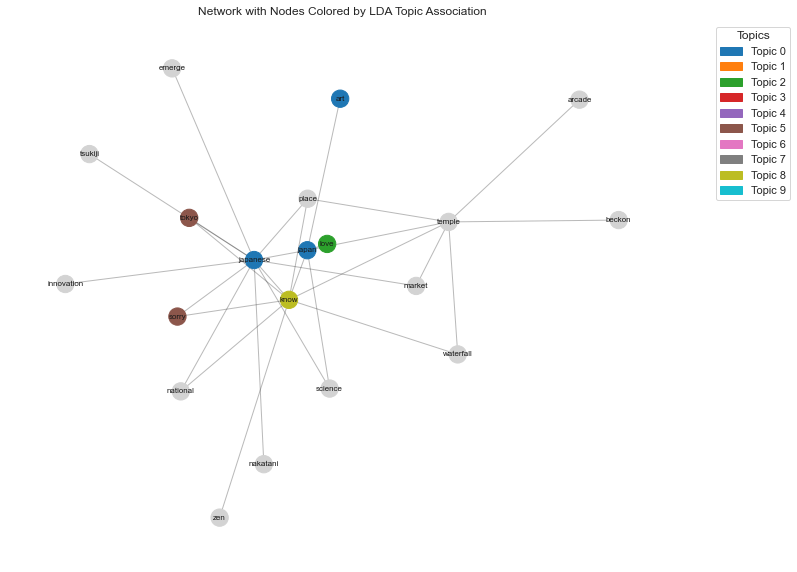

In [43]:
import matplotlib.patches as mpatches

# Number of top words to extract per topic
num_top_words = 10
vocab = vect.get_feature_names()  # from your TfidfVectorizer
topic_top_words = {}

# Extract top words for each topic
for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[-num_top_words:][::-1]
    topic_top_words[topic_idx] = [vocab[i] for i in top_indices]
    print(f"Topic {topic_idx+1}: {topic_top_words[topic_idx]}")

# Create a mapping: word -> list of topics where it appears in the top words
node_topic_mapping = {}
for topic_idx, words in topic_top_words.items():
    for word in words:
        if word in YT_jp_nw.nodes():
            node_topic_mapping.setdefault(word, []).append(topic_idx)

# For visualization, assign a color based on the first associated topic.
# (You can expand this if a node is linked to multiple topics.)
color_map = []
for node in YT_jp_nw.nodes():
    if node in node_topic_mapping:
        # Use the topic index to select a color from a colormap (e.g., tab10)
        topic_idx = node_topic_mapping[node][0]
        color = plt.cm.tab10(topic_idx)
    else:
        color = 'lightgrey'
    color_map.append(color)

# Visualize the full network with nodes colored by their LDA topic association
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(YT_jp_nw, seed=42)
nx.draw_networkx_nodes(YT_jp_nw, pos, node_color=color_map, node_size=300)
nx.draw_networkx_edges(YT_jp_nw, pos, alpha=0.3)
nx.draw_networkx_labels(YT_jp_nw, pos, font_size=8)
plt.title("Network with Nodes Colored by LDA Topic Association")
plt.axis('off')

# Create legend handles for each topic using the tab10 colormap
num_topics = lda_model.components_.shape[0]
legend_handles = [
    mpatches.Patch(color=plt.cm.tab10(topic_idx), label=f"Topic {topic_idx}")
    for topic_idx in range(num_topics)
]

# Add the legend to the plot
plt.legend(handles=legend_handles, title="Topics", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()


In [44]:
# Construct a DataFrame with topics and their top words
df_topics = pd.DataFrame({
    'Topic': [f"Topic {i+1}" for i in range(len(topic_top_words))],
    'Top Words': [', '.join(topic_top_words[i]) for i in range(len(topic_top_words))]
})

df_topics.head(10)

,Topic,Top Words
0,Topic 1,"film, girl, cute, art, japanese, tear, ruby, b..."
1,Topic 2,"wow, mochi, monk, advertise, need, word, good,..."
2,Topic 3,"japan, love, beautiful, want, like, cool, vide..."
3,Topic 4,"nakagawa, wish, ninja, hiroshima, japan, smoot..."
4,Topic 5,"god, beauty, impress, night, tang, shoot, peop..."
5,Topic 6,"sorry, goosebump, fukushima, kyoto, fine, situ..."
6,Topic 7,"see, youtube, look, good, japan, proud, cry, w..."
7,Topic 8,"great, awesome, video, japan, greet, miss, lov..."
8,Topic 9,"song, music, video, movie, background, edit, a..."
9,Topic 10,"amaze, video, nice, wonderful, glad, japan, co..."
